# Análisis SHAP - TMT → Age (SVR)

In [2]:
import sys
from pathlib import Path

# Find project root (directory containing src/)
_p = Path().resolve()
while not (_p / 'src').is_dir() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

DATASET = "tmt_age"
MODEL = "SVR"
TASK = "regression"
TIMESTAMP = "2026-02-03_2053"

In [3]:
import pandas as pd
import numpy as np
from src.model.datasetbuilder.dataset_builder import DatasetBuilder

builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset(DATASET)

print(f"Dataset: {DATASET}")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Target: {target_name}")
print(f"Age - mean: {y.mean():.1f}, std: {y.std():.1f}, range: [{y.min()}, {y.max()}]")

Dataset: tmt_age
Samples: 362, Features: 134
Target: age
Age - mean: 31.8, std: 10.0, range: [18, 77]


In [4]:
from src.model.shap.run_shap import run_shap

shap_explanations, target_name = run_shap(
    task=TASK,
    dataset_name=DATASET,
    timestamp=TIMESTAMP,
    model_name_to_explain=MODEL,
)

print(f"Explanations: {len(shap_explanations)} folds")

/home/gianlucacapelo/Research/datapruebas_analysis/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers._permutation.PermutationExplainer | link: CPUDispatcher
[SHAP] backend: shap.explainers.

In [5]:
from src.model.shap.analyze_shap_results import analyze_shap_results

shap_df = analyze_shap_results(shap_explanations, task=TASK, fillna_zero=False)
print(f"Features analizados: {len(shap_df)}")
shap_df.head(20)

Features analizados: 22


,mean_abs_shap,freq_selection
non_cut_search_distance_PART_A,1.087883,1.000000
non_cut_total_distance_PART_A,0.929996,1.000000
non_cut_intra_target_time_PART_B,0.780756,0.035912
mean_speed_PART_B,0.628569,0.011050
rt_PART_B,0.507539,0.953039
non_cut_search_avg_speed_PART_B,0.464889,1.000000
non_cut_search_avg_speed_PART_A,0.460287,1.000000
non_cut_total_distance_PART_B,0.454503,1.000000
non_cut_mean_speed_PART_A,0.410785,1.000000
non_cut_mean_speed_PART_B,0.355752,1.000000


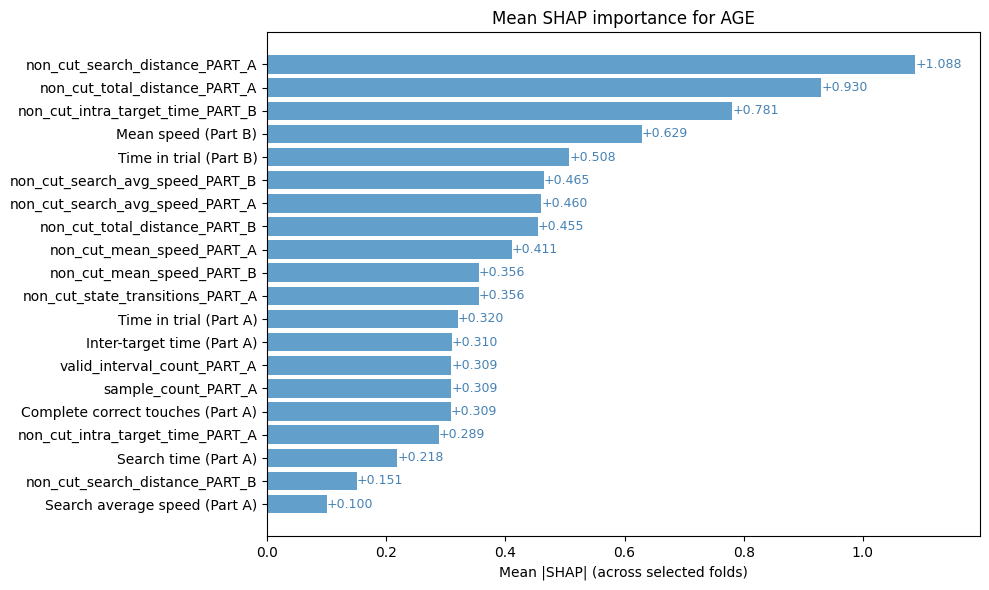

Figure saved to: /home/gianlucacapelo/Research/datapruebas_analysis/analysis/figures/shap_summary_tmt_age_SVR.png


<Figure size 640x480 with 0 Axes>

In [6]:
import os
import matplotlib.pyplot as plt
from src.model.shap.analyze_shap_results import plot_shap_summary

ANALYSIS_FIGURES_DIR = os.path.join(str(_p), "analysis", "figures")
os.makedirs(ANALYSIS_FIGURES_DIR, exist_ok=True)

plot_shap_summary(
    shap_df,
    is_classification=False,
    target_col=target_name,
    top_n=20,
)

save_path = os.path.join(ANALYSIS_FIGURES_DIR, f"shap_summary_{DATASET}_{MODEL}.png")
plt.savefig(save_path, bbox_inches="tight", dpi=300)
print(f"Figure saved to: {save_path}")

In [7]:
print(f"=== Top 10 Features - SHAP Importance ({MODEL}) ===")
print(f"{'Feature':<50} {'mean |SHAP|':>12} {'freq_selection':>16}")
print("-" * 80)
for feat, row in shap_df.head(10).iterrows():
    print(f"{feat:<50} {row['mean_abs_shap']:>12.4f} {row['freq_selection']:>15.1%}")

=== Top 10 Features - SHAP Importance (SVR) ===
Feature                                             mean |SHAP|   freq_selection
--------------------------------------------------------------------------------
non_cut_search_distance_PART_A                           1.0879          100.0%
non_cut_total_distance_PART_A                            0.9300          100.0%
non_cut_intra_target_time_PART_B                         0.7808            3.6%
mean_speed_PART_B                                        0.6286            1.1%
rt_PART_B                                                0.5075           95.3%
non_cut_search_avg_speed_PART_B                          0.4649          100.0%
non_cut_search_avg_speed_PART_A                          0.4603          100.0%
non_cut_total_distance_PART_B                            0.4545          100.0%
non_cut_mean_speed_PART_A                                0.4108          100.0%
non_cut_mean_speed_PART_B                                0.3558       